#**Laboratorio di Introduzione alla Matematica Computazionale - Esercizi in Julia**

##**Esercitazione 4: Sistemi di funzioni iterate e frattali**

---
# Setup iniziale
Carichiamo le librerie necessarie.

In [ ]:
using Plots
using LinearAlgebra

---
#1. Fern Fractal (Felce di Barnsley)

Il *fern fractal*, o *felce di Barnsley*, è un insieme frattale così chiamato perchè prende la forma di una foglia di felce. Si ottiene disegnando una successione di punti del piano generati tramite un processo casuale che ora descriviamo.

Rappresenteremo un punto sul piano per mezzo del vettore ${\bf x}\in\mathbb{R}^2$ delle sue coordinate. La successione che definisce il *fern fractal* è generata applicando successivamente delle trasformazioni affini del tipo

$$
{\bf x}\rightarrow A_i{\bf x}+{\bf b}_i,
$$

dove $A_i$ è una matrice $2\times 2$ e ${\bf b}_i$ un vettore di dimensione $2$. Nella costruzione del *fern fractal* si usano quattro diverse trasformazioni di questo tipo, ciascuna scelta con una certa probabilità. Cominciamo studiando la prima di queste trasformazioni, quella che viene scelta con maggiore probabilità. Essa è definita da

$$
A_1=\left[\begin{array}{cc}
0.85&0.04\\-0.04&0.85
\end{array}\right],\qquad
{\bf b}_1=\left[\begin{array}{c}0\\1.6
\end{array}\right].
$$

L'effetto di questa trasformazione è di ruotare e ``accorciare'' il vettore ${\bf x}$, e poi aggiungere 1.6 alla seconda componente. L'applicazione ripetuta di questa trasformazione costruisce tante copie sempre più piccole delle foglie e del gambo della felce.


**Esercizio 1**. Scegliamo
${\bf x}=\left[1,1\right]^T$. Scrivere un codice Juilia che applichi 50 volte la trasformazione definita sopra e disegni sul piano tutti i punti ottenuti.<br>
(Suggerimento: anzichè usare il comando `plot` ogni volta che si calcola un nuovo punto, è preferibile memorizzare dapprima tutti i punti calcolati in un array `S` di dimensioni $2\times 50$, e poi disegnarli con il comando

`plot(S[1,:], S[2,:], label="", color=:green, aspect_ratio=:equal, ticks = false)`.  

Le altre tre trasformazioni usate per il *fern fractal* sono definite da

\begin{eqnarray*}
&& A_2=\left[\begin{array}{cc}
0.20&-0.26\\0.23&0.22
\end{array}\right],\qquad
&{\bf b}_2=\left[\begin{array}{c}0\\1.6
\end{array}\right]\\
&& A_3=\left[\begin{array}{cc}
-0.15&0.28\\0.26&0.24
\end{array}\right],\qquad
&{\bf b}_3=\left[\begin{array}{c}0\\0.44
\end{array}\right]\\
&& A_4=\left[\begin{array}{cc}
0&0\\0&0.16
\end{array}\right],\qquad
&{\bf b}_4=\left[\begin{array}{c}0\\0
\end{array}\right].
\end{eqnarray*}

e hanno rispettivamente l'effetto di generare la foglia in basso a destra, la foglia in basso a sinistra, e il gambo della felce.

**Esercizio 2**. Ripetere l'Esercizio 1 per le altre tre trasformazioni appena definite.

Passiamo ora a costruire il *fern fractal*. Siano

$$
p_1=0.85,\qquad p_2=0.92,\qquad p_3=0.99,\qquad p_4=1.
$$

Prendiamo ${\bf x}_1=\left[\begin{array}{c}0.5\\0.5
\end{array}\right]$ come punto iniziale. Per $k=1,2,\ldots$,


* scegliamo in modo casuale, con distribuzione uniforme, un numero reale $r$ compreso tra 0 e 1;

* se $r\leq p_1$ poniamo $i=1$, se $p_1<r\leq p_2$ poniamo $i=2$, se $p_2<r\leq p_3$ poniamo $i=3$, altrimenti si pone $i=4$;

* definiamo ${\bf x}_{k+1}=A_i {\bf x}_k + {\bf b}_i$.

**Esercizio 3**.
Scrivere una function `fern(m)` che prende in ingresso l'intero positivo `m` e disegna sul piano i punti rappresentati dai vettori $\{{\bf x}_k\}$ per $k=1,\ldots,m$.

Suggerimenti:
* si potrà usare la funzione `rand` per generare il numero casuale $r$;
* è consigliabile, come suggerito in preceedenza, memorizzare tutti gli elementi della successione in un array e visualizzarli alla fine con un unico comando `plot`, oppore `scatter` (se si vuole che i vari punti appaiano con marcatori disgiunti);
* si potrà usare la specifica `axis=false` per rimuovere gli assi cartesiani dalla figura, e `aspect_ratio=:equal` per forzare la stessa scale su entrambi gli assi.

Qui sotto è raffigurata l'immagine ottenuta per $m=5000$.

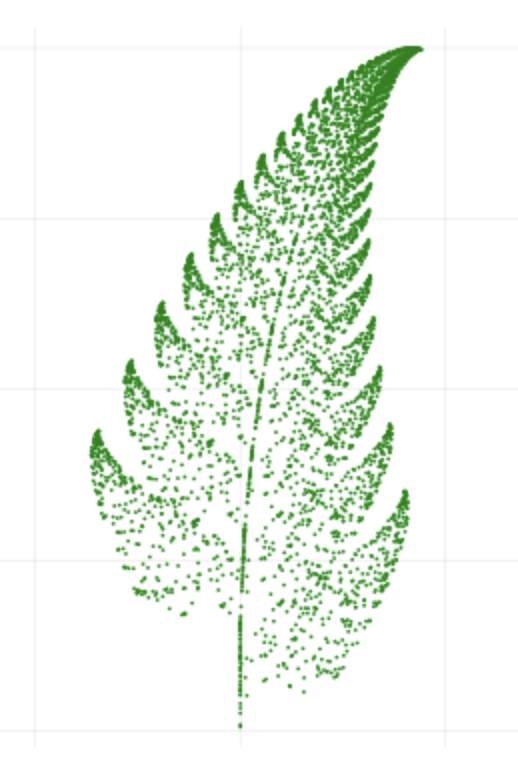

**Esercizio 4**. Per capire meglio come si crea il *fern fractal*, modificate la function `fern` per creare una nuova function `ferncolor` che disegna i punti calcolati in colori diversi a seconda delle trasformazioni usate (per esempio, i verde i punti ottenuti dalla prima trasformazione, in rosso quelli ottenuti dalla seconda, in blu quelli ottenuti dalla terza, in nero quelli ottenuti dalla quarta).

Dovreste ottenere una figura simile a questa:

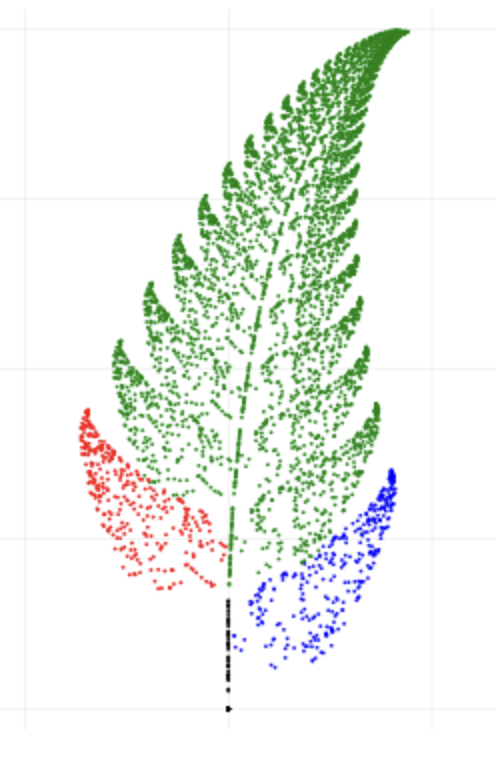

**Esercizio 5**. Che cosa succede modificando gli elementi di $A_i$ e ${\bf b}_i$?

Provate ad usare i parametri suggeriti alla pagina

https://www.dcnicholls.com/byzantium/ferns/fractal.html

per disegnare felci diverse.

---
#2. Triangolo di Sierpinski

In questa sezione generalizziamo l'iterazione che genera il *fern fractal* per costruire il *triangolo di Sierpinski*.

Sia $n$ un intero maggiore di 1, siano $A_1,\ldots,A_n$ matrici reali $2\times 2$ assegnate e siano ${\bf b}_1,\ldots,{\bf b}_n$ vettori (colonna) reali di lunghezza 2 assegnati. Consideriamo la matrice $C$, di dimensioni $2n\times 3$, cosi` definita:
$$
C=\left[\begin{array}{cc}
A_1 & {\bf b}_1\\
A_2 & {\bf b}_2\\
\vdots & \vdots \\
A_n & {\bf b}_n\\
\end{array}\right].
$$


**Esercizio 6**.
Scrivere una function `fract(C,m)` che disegni i punti sul piano generati nel modo seguente:
<ul>
<li>si costruisce il vettore <tt>dets</tt> di dimensione $n$, tale che la $j$-esima componente di <tt>dets</tt> contenga $|{\rm det}(A_j)|$

(suggerimento: usare la funzione `det`);
</li>
<li>si modifica il vettore <tt>dets</tt> come segue:

```julia#
dets = max.(dets, maximum(dets)/(25*n))
dets = dets ./ sum(dets)
```    
</li>
<li> si crea il vettore <tt>p</tt> di dimensione $n$ con componenti

`0`, `dets(1)`, `dets(1)`+`dets(2)`, ..., `dets(1)`+...+`dets(n-1)`

(suggerimento: potreste trovare conveniente l'uso del comando `cumsum`)
</li>

<li> si costruisce una successione di vettori
$\{{\bf x}_k\}_{k=1,2,\ldots}$ in questo modo: si parte da ${\bf x}_1$ scelto in modo casuale, dopodichè per ciascun $k=1,2,\ldots$ si sceglie un numero casuale $r$ con distribuzione di probabilità uniforme in $[0,1]$, si pone

```julia#
i = sum(p .< r)
```

e si definisce
$$
{\bf x}_{k+1}=A_i {\bf x}_k +{\bf b}_i;
$$
<li> per $k=21,\, 22,\, \ldots, 20+m$ si disegna sul piano il punto le cui coordinate sono gli elementi del vettore ${\bf x}_k$.</li>
</ul>

Si applichi quindi la function `fract(C,m)` alle matrici seguenti (con opportune scelte di `m`):
$$
S=\left[\begin{array}{ccc}
0.5 & 0 & 0\\
0 & 0.5 & 0\\
0.5 & 0 & 0.5\\
0 & 0.5 & 0\\
0.5 & 0 & 0.25\\
0 & 0.5 & 0.5\\
\end{array}\right],
$$
e
$$
K=\left[\begin{array}{ccc}
t & 0 & 0\\
0 & t & 0\\
s & -x & t\\
x & s & 0\\
s & x & 0.5\\
-x & s & x\\
t & 0 & t_2\\
0 & t & 0\\
\end{array}\right],
$$
dove $x=\frac13\sin(\pi/3)$, $s=1/6$, $t=1/3$, $t_2=2/3$.

La function `fract(C,m)` applicata alla matrice $S$ disegna il triangolo di Sierpinski (figura qui sotto).

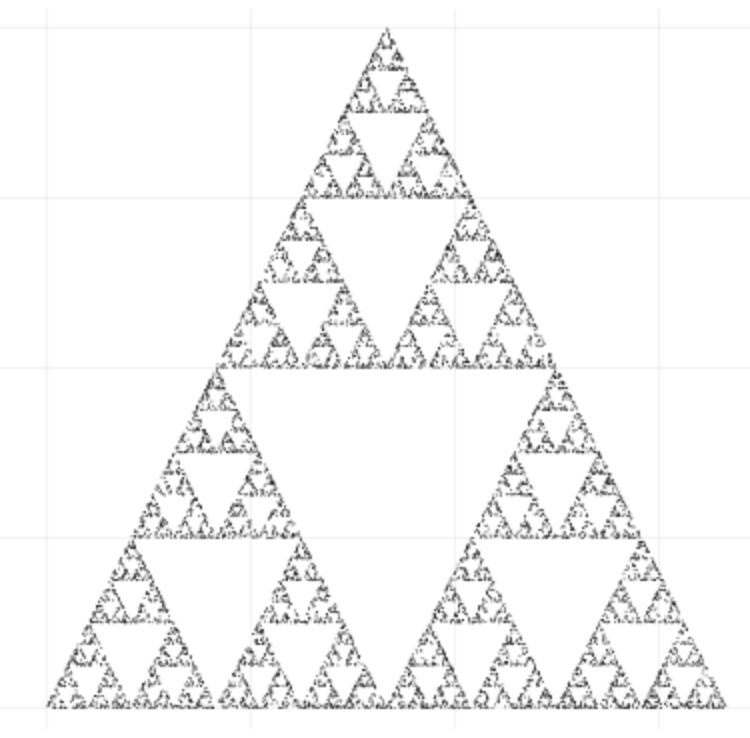

Che cosa si ottiene usando la matrice $K$?


---
#3. The chaos game

Consideriamo tre punti nel piano (uno rosso, uno verde, uno blu) posti ai vertici di un triangolo equilatero.
Poi scegliamo un quarto punto (nero) in una posizione qualsiasi.

Il gioco consiste nel far muovere il punto nero secondo le regole seguenti. Ad ogni turno, lanciamo un dado a sei facce. Se il risultato è 1 o 2, muoviamo il punto nero in direzione del punto rosso, spostandolo di una lunghezza pari a metà della distanza che separava i due punti all'inizio del turno. Se il risultato è 3 o 4, muoviamo il punto nero verso il punto verde, percorrendo sempre metà della distanza tra i due punti. Se il risultato è 5 o 6, muoviamo il punto nero verso il punto blu, sempre rispettando la regola di coprire metà della distanza.

**Esercizio 7**. Scrivere una function `chaos(m)` che simuli il gioco descritto. Come al solito, `m` è un intero positivo. La function dovrà disegnare nel piano i punti generati dal gioco dal turno $21$ al turno $20+m$. Che cosa appare?

Che cosa succede se si colorano i punti a seconda della mossa che li ha generati (cioè si disegnano in rosso i punti generati da una mossa verso il vertice rosso, in verde i punti generati da una mossa verso il vertice verde, in blu i punti generati da una mossa verso il vertice blu)?

Che cosa succede se si modificano i vertici del triangolo (che quindi non sarà più necessariamente equilatero)?


**Osservazione**. In questa esercitazione abbiamo creato dei frattali a partire da trasformazioni  lineari o affini. Questo procedimento si può estendere anche a trasformazioni non lineari: è il caso,  per esempio, delle *fractal flames* proposte da Scott Draves. Trovate informazioni in materia anche su Wikipedia: https://en.wikipedia.org/wiki/Fractal\_flame
e una descrizione molto dettagliata è disponibile qui: https://flam3.com/flame\_draves.pdf.
